In [2]:
# CAMB v2 LateDE

import numpy as np
import matplotlib.pyplot as plt
import camb
import os

# Check which CAMB is installed
print(
    "Using CAMB %s installed at %s"
    % (camb.__version__, os.path.dirname(camb.__file__))
)

Using CAMB 2.0.1 installed at /gpfs/scratch/pit-roman-hlis/Diogo/CAMBv2LateDE/camb


In [3]:
# Common cosmological parameters
base_params = dict(
    H0=70,ombh2=0.02238280,omch2=0.1201075,TCMB=2.7255,dark_energy_model="ppf",
    # Neutrinos
    omnuh2=0,num_nu_massless=3.044,num_nu_massive=0,nu_mass_degeneracies=[0],nu_mass_numbers=[0],
    # Initial power spectrum
    As=2.100549e-9,ns=0.9660499,YHe=0.246,WantTransfer=True
    )

# ------------------------------------------------------------
# DEmodel = 1: constant w
# ------------------------------------------------------------
cosmology_w = camb.set_params(**base_params,DEmodel=1,w0=-0.8,)

# ------------------------------------------------------------
# DEmodel = 2: CPL
# w(a) = w0 + (1-a) w1
# ------------------------------------------------------------
cosmology_cpl = camb.set_params(**base_params,DEmodel=2,w0=-0.8,w1=-0.3,)

# ------------------------------------------------------------
# DEmodel = 3: piecewise-constant binned w(z)
# ------------------------------------------------------------
z_knot = [0.5 * (i + 1) for i in range(20)]
w_knot = [-1 + 0.3 * np.sin(i) for i in range(20)]

cosmology_bins = camb.set_params(**base_params,DEmodel=3,z_knot=z_knot,w_knot=w_knot,)

# Background sampling
scale_factor = np.logspace(-2, 0, 2000)
redshift = 1 / scale_factor - 1

# ------------------------------------------------------------
# Compute dark-energy background evolution
# ------------------------------------------------------------
results_w = camb.get_results(cosmology_w)
rho_w, wde_w = results_w.get_dark_energy_rho_w(scale_factor)

results_cpl = camb.get_results(cosmology_cpl)
rho_cpl, wde_cpl = results_cpl.get_dark_energy_rho_w(scale_factor)

results_bins = camb.get_results(cosmology_bins)
rho_bins, wde_bins = results_bins.get_dark_energy_rho_w(scale_factor)

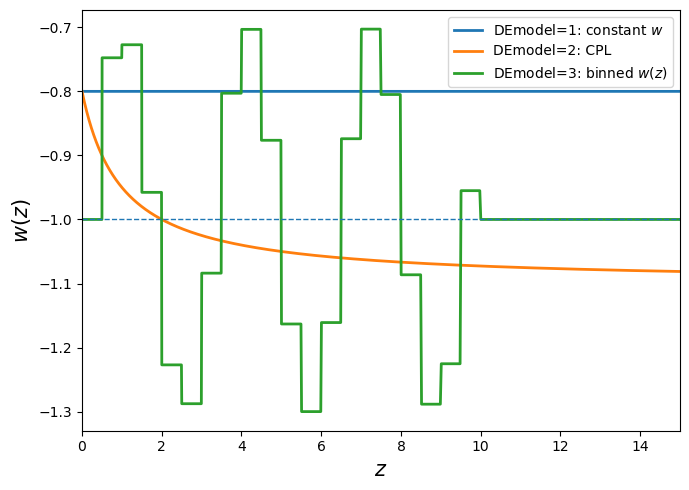

In [4]:
# ------------------------------------------------------------
# Plot w(z)
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

plt.plot(redshift,wde_w,lw=2,label=r"DEmodel=1: constant $w$")
plt.plot(redshift,wde_cpl,lw=2,label=r"DEmodel=2: CPL")
plt.plot(redshift,wde_bins,lw=2,label=r"DEmodel=3: binned $w(z)$")

plt.axhline(-1, lw=1, ls="--")

plt.xlim(0, 15)
plt.ylabel(r"$w(z)$", fontsize=15)
plt.xlabel(r"$z$", fontsize=15)
plt.legend(loc="best")
plt.tight_layout()

# plt.savefig("latede_models_w.pdf")
plt.show()

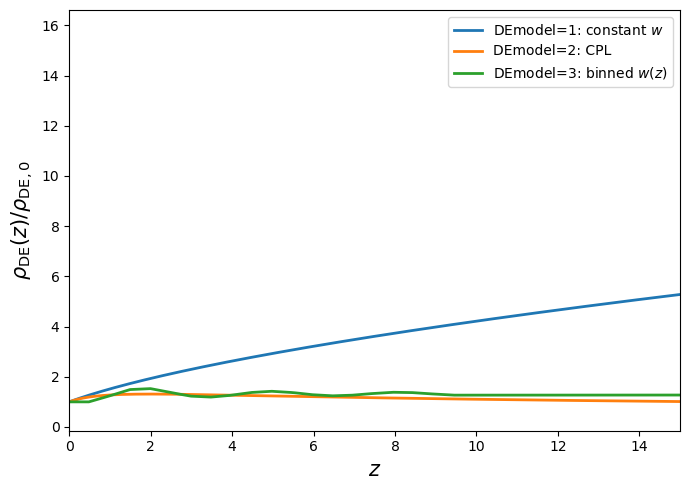

In [5]:
# ------------------------------------------------------------
# Plot rho_DE(a) / rho_DE(a=1)
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

plt.plot(redshift,rho_w / rho_w[-1],lw=2,label=r"DEmodel=1: constant $w$")
plt.plot(redshift,rho_cpl / rho_cpl[-1],lw=2,label=r"DEmodel=2: CPL")
plt.plot(redshift,rho_bins / rho_bins[-1],lw=2,label=r"DEmodel=3: binned $w(z)$")

plt.xlim(0, 15)
plt.ylabel(r"$\rho_{\rm DE}(z)/\rho_{\rm DE,0}$", fontsize=15)
plt.xlabel(r"$z$", fontsize=15)
plt.legend(loc="best")
plt.tight_layout()
# plt.savefig("latede_models_rho.pdf")
plt.show()